In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
os.environ["KERAS_BACKEND"] = 'torch'
import keras

def load_dataset():
    train_fn = 'data/train_signs.h5'
    train_dataset = h5py.File(train_fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:])
    Y_train = np.array(train_dataset["train_set_y"][:]) 

    test_fn = 'data/test_signs.h5'
    test_dataset =  h5py.File(test_fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) 
    Y_test = np.array(test_dataset["test_set_y"][:]) 

    classes = np.array(test_dataset["list_classes"][:]) 
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes

train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=', train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


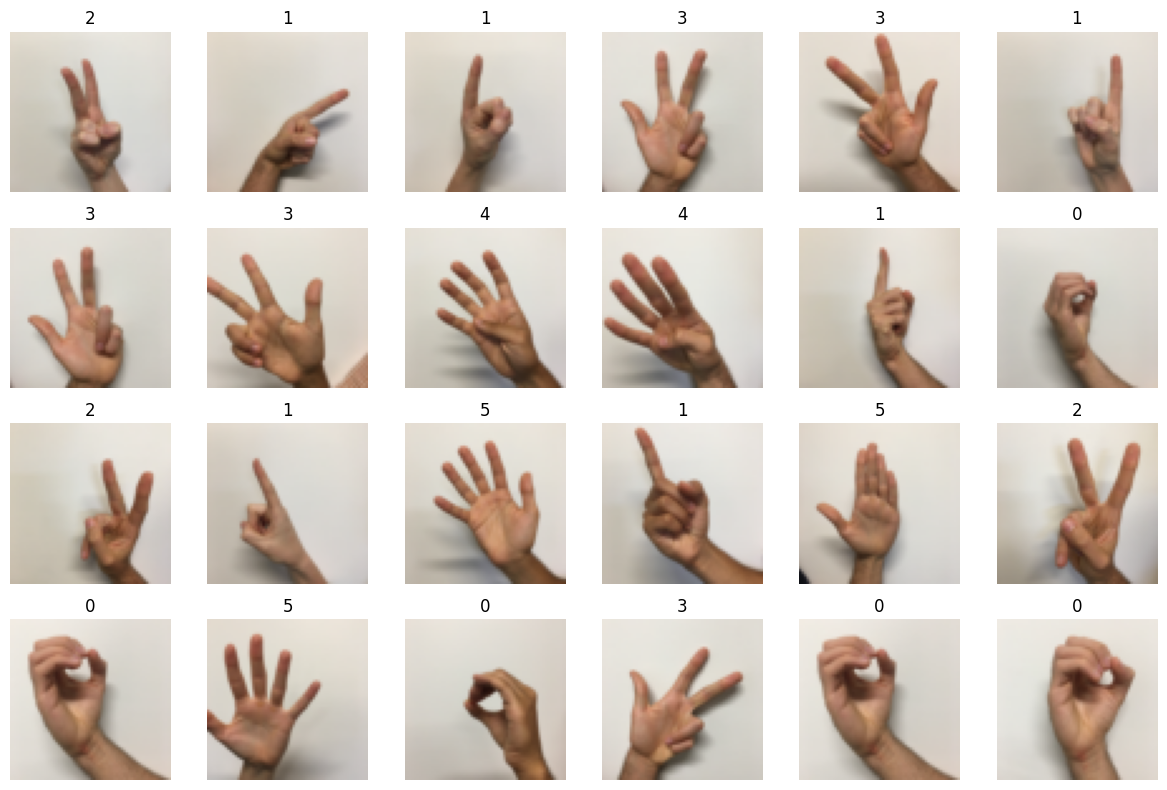

In [3]:
def display_samples_in_grid(X, n_rows, n_cols=None, y=None):
    if n_cols is None:
        n_cols = n_rows
    indices = np.random.randint(0, len(X), n_rows * n_cols)
    plt.figure(figsize=(12, 8))
    for i in range(n_rows):
        for j in range(n_cols):
            index = n_cols * i + j
            ax = plt.subplot(n_rows, n_cols, index + 1)
            ax.imshow(X[indices[index]])
            if y is not None:
                plt.title(y.flatten()[indices[index]])
            plt.axis('off')
    plt.tight_layout(h_pad=1, w_pad=1)
    plt.show()

display_samples_in_grid(train_data, n_rows=4, n_cols=6, y=train_labels.T)

In [4]:
from keras.utils import to_categorical

dimData = np.prod(train_data.shape[1:]) 
nClasses = len(classes)      

print('Entry size:', dimData)
print('Num of classes:', nClasses)

X_train_norm = train_data.astype('float32') / 255
X_test_norm = test_data.astype('float32') / 255

Y_train_flat = train_labels.flatten()
Y_test_flat  = test_labels.flatten()

Y_train_oh = to_categorical(Y_train_flat, nClasses)
Y_test_oh  = to_categorical(Y_test_flat, nClasses)


Entry size: 12288
Num of classes: 6


In [5]:
def plot_history(history, title=''):
    plt.figure(figsize=[14, 5])

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], 'r', linewidth=2)
    plt.plot(history.history['val_loss'], 'b', linewidth=2)
    plt.legend(['Training Loss', 'Validation Loss'], fontsize=13)
    plt.xlabel('Epochs', fontsize=13)
    plt.ylabel('Loss', fontsize=13)
    plt.title(f'Loss — {title}', fontsize=14)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], 'r', linewidth=2)
    plt.plot(history.history['val_accuracy'], 'b', linewidth=2)
    plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=13)
    plt.xlabel('Epochs', fontsize=13)
    plt.ylabel('Accuracy', fontsize=13)
    plt.title(f'Accuracy — {title}', fontsize=14)

    plt.tight_layout()
    plt.show()

c:\Users\ihorz\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,936,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,938,054 (15.02 MB)

 Trainable params: 3,938,054 (15.02 MB)

 Non-trainable params: 0 (0.00 B)

X_test_flat.shape: (1080, 64, 64, 3)
Y_test_oh.shape: (120, 64, 64, 3)
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1704 - loss: 3.4963 - val_accuracy: 0.3167 - val_loss: 1.7682
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3176 - loss: 1.6695 - val_accuracy: 0.5917 - val_loss: 1.4354
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.4880 - loss: 1.3805 - val_accuracy: 0.5167 - val_loss: 1.2220
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5741 - loss: 1.1437 - val_accuracy: 0.6917 - val_loss: 1.0075
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6676 - loss: 0.9348 - val_accuracy: 0.8000 - val_loss: 0.7516
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7019 - loss: 0.8517 - val_accuracy: 0.8167 - val_loss: 0.7045
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7657 - loss: 0.7099 - val_accuracy: 0.7250 - val_loss: 0.6822
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s

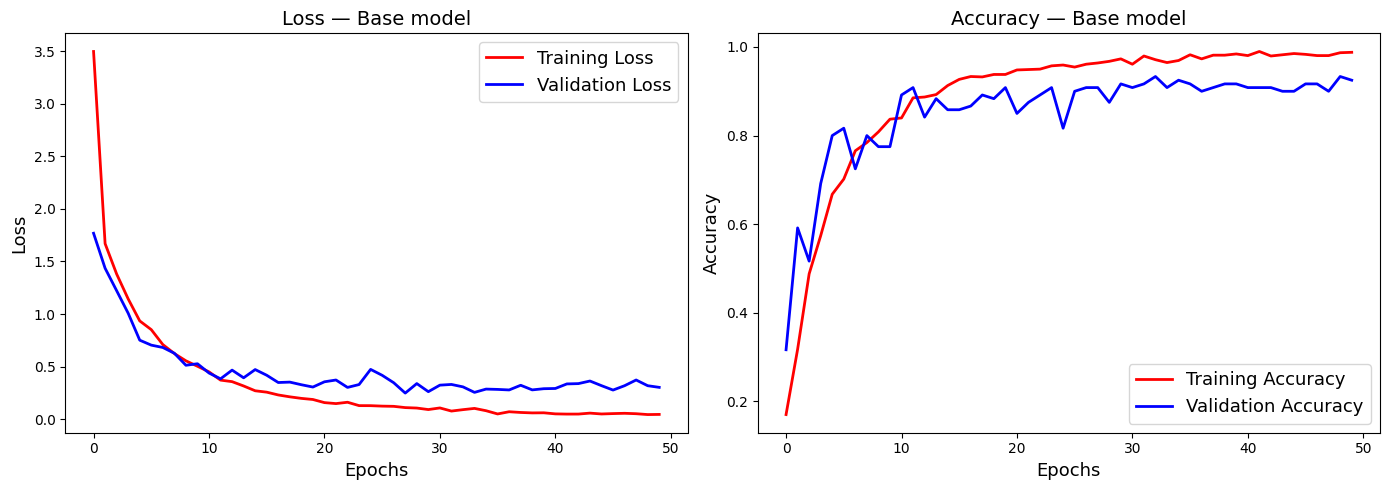

Base model — Test Loss: 0.3030, Test Accuracy: 0.9250


In [6]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten

model_base = Sequential([
    Conv2D(32, (3, 3), activation = 'relu', input_shape = (64, 64, 3)),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(nClasses, activation='softmax')
])

model_base.compile(optimizer='rmsprop',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

model_base.summary()
print(f"X_test_flat.shape: {train_data.shape}")
print(f"Y_test_oh.shape: {test_data.shape}")

history_base = model_base.fit(X_train_norm, Y_train_oh,
                               batch_size=32, epochs=50, verbose=1,
                               validation_data=(X_test_norm, Y_test_oh))

plot_history(history_base, 'Base model')

loss, acc = model_base.evaluate(X_test_norm, Y_test_oh, verbose=0)
print(f'Base model — Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 229ms/step - accuracy: 0.1852 - loss: 1.8459 - val_accuracy: 0.2083 - val_loss: 1.7845
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.2769 - loss: 1.7481 - val_accuracy: 0.4000 - val_loss: 1.6227
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.4009 - loss: 1.5568 - val_accuracy: 0.4667 - val_loss: 1.3572
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.4694 - loss: 1.3640 - val_accuracy: 0.6667 - val_loss: 1.1277
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step - accuracy: 0.5741 - loss: 1.1650 - val_accuracy: 0.6250 - val_loss: 0.9754
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 213ms/step - accuracy: 0.6000 - loss: 1.0552 - val_accuracy: 0.6667 - val_loss: 0.8460
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.6185 - loss: 0.9963 - val_accuracy: 0.7917 - val_loss: 0.6852
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 215ms/step - accuracy: 0.6630 - loss: 0.8828 - val_accuracy: 0.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (32, 64, 64, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 62, 62, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 31, 31, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 29, 29, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 12544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 128)              │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 6)                │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,877,780 (18.61 MB)

 Trainable params: 1,625,926 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,251,854 (12.40 MB)

X_test_flat.shape: (1080, 64, 64, 3)
Y_test_oh.shape: (120, 64, 64, 3)


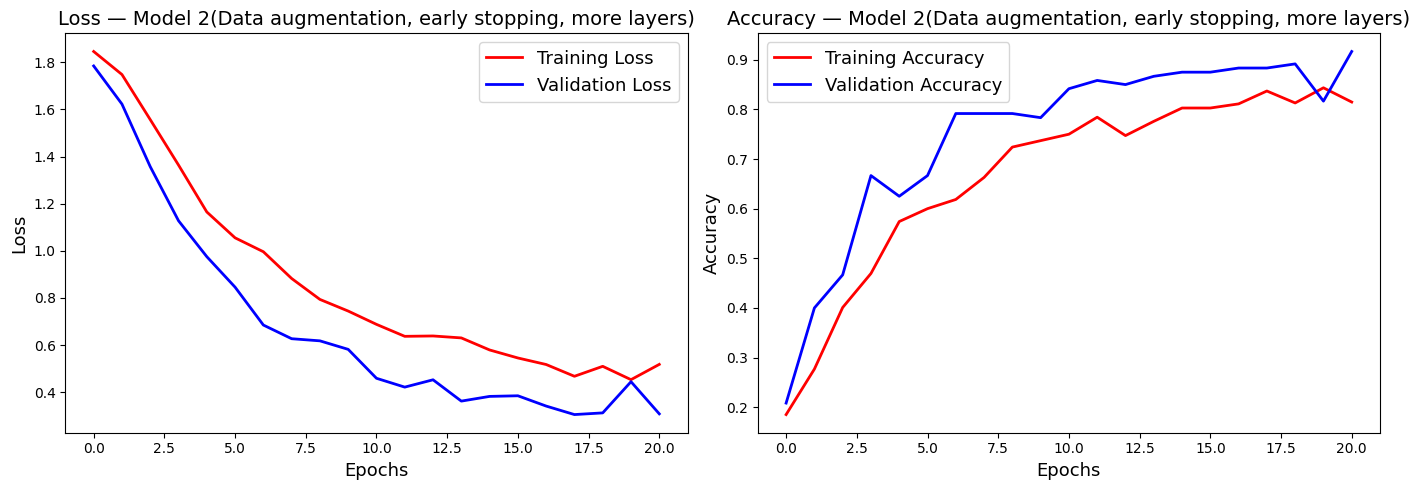

Model 2 — Test Loss: 0.3085, Test Accuracy: 0.9167


In [7]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
from keras import layers, models

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model2 = Sequential([
    data_augmentation,
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(), 
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(nClasses, activation='softmax')
])

model2.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history2 = model2.fit(X_train_norm, Y_train_oh,
                    epochs=50, 
                    batch_size=32,
                    validation_data=(X_test_norm, Y_test_oh),
                    callbacks = [callback])

model2.summary()
print(f"X_test_flat.shape: {train_data.shape}")
print(f"Y_test_oh.shape: {test_data.shape}")

plot_history(history2, 'Model 2(Data augmentation, early stopping, more layers)')

loss, acc = model2.evaluate(X_test_norm, Y_test_oh, verbose=0)
print(f'Model 2 — Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.2093 - loss: 1.7921 - val_accuracy: 0.4583 - val_loss: 1.6674
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.2963 - loss: 1.6409 - val_accuracy: 0.4417 - val_loss: 1.4669
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.4074 - loss: 1.4815 - val_accuracy: 0.5167 - val_loss: 1.2007
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.4509 - loss: 1.3877 - val_accuracy: 0.6333 - val_loss: 1.1748
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.4769 - loss: 1.2843 - val_accuracy: 0.6833 - val_loss: 0.9915
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - accuracy: 0.5259 - loss: 1.1910 - val_accuracy: 0.7250 - val_loss: 0.8744
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.5639 - loss: 1.1191 - val_accuracy: 0.7750 - val_loss: 0.7171
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - accuracy: 0.5907 - loss: 1.0242 - val_accuracy: 0.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (32, 64, 64, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 62, 62, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 31, 31, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 29, 29, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (32, 12544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 128)              │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 6)                │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,877,780 (18.61 MB)

 Trainable params: 1,625,926 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,251,854 (12.40 MB)

X_test_flat.shape: (1080, 64, 64, 3)
Y_test_oh.shape: (120, 64, 64, 3)


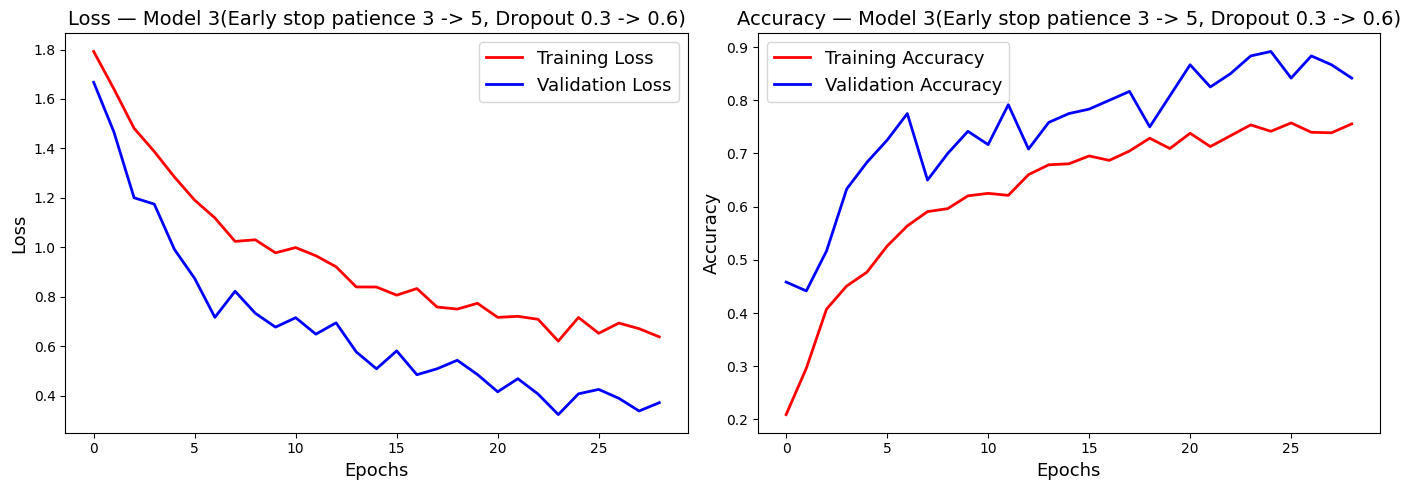

Model 3 — Test Loss: 0.3720, Test Accuracy: 0.8417


In [8]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
model3 = Sequential([
    data_augmentation,
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(), 
    Dense(128, activation='relu'),
    Dropout(0.6),
    Dense(nClasses, activation='softmax')
])

model3.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history3 = model3.fit(X_train_norm, Y_train_oh,
                    epochs=50, 
                    batch_size=32,
                    validation_data=(X_test_norm, Y_test_oh),
                    callbacks = [callback])

model3.summary()
print(f"X_test_flat.shape: {train_data.shape}")
print(f"Y_test_oh.shape: {test_data.shape}")

plot_history(history3, 'Model 3(Early stop patience 3 -> 5, Dropout 0.3 -> 0.6)')

loss, acc = model3.evaluate(X_test_norm, Y_test_oh, verbose=0)
print(f'Model 3 — Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.1657 - loss: 2.9290 - val_accuracy: 0.2500 - val_loss: 1.7957
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step - accuracy: 0.1898 - loss: 2.4649 - val_accuracy: 0.3000 - val_loss: 1.8746
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step - accuracy: 0.3917 - loss: 1.7041 - val_accuracy: 0.4833 - val_loss: 1.2641
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - accuracy: 0.4463 - loss: 1.4373 - val_accuracy: 0.5833 - val_loss: 1.0130
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - accuracy: 0.4907 - loss: 1.2779 - val_accuracy: 0.5917 - val_loss: 1.0570
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - accuracy: 0.5241 - loss: 1.2180 - val_accuracy: 0.7000 - val_loss: 0.8560
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - accuracy: 0.5704 - loss: 1.1094 - val_accuracy: 0.7417 - val_loss: 0.8210
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step - accuracy: 0.6352 - loss: 1.0181 - val_accuracy: 0.

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (32, 64, 64, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 62, 62, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 31, 31, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 29, 29, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (32, 12544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (32, 128)              │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (32, 6)                │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,877,780 (18.61 MB)

 Trainable params: 1,625,926 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,251,854 (12.40 MB)

X_test_flat.shape: (1080, 64, 64, 3)
Y_test_oh.shape: (120, 64, 64, 3)


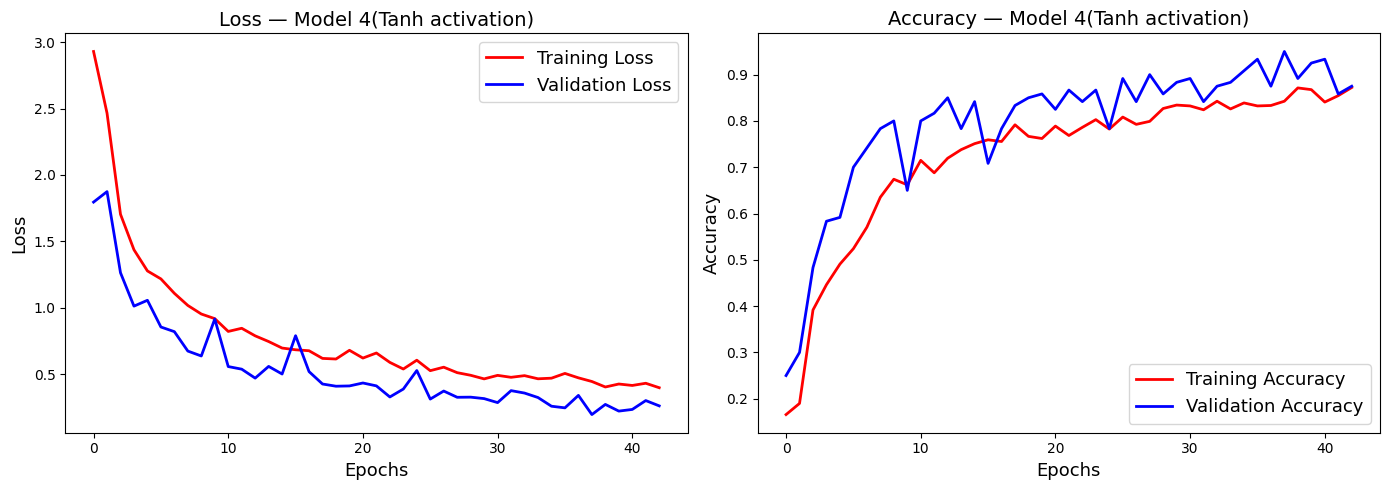

Model 4 — Test Loss: 0.2626, Test Accuracy: 0.8750


In [14]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
model4 = Sequential([
    data_augmentation,
    Conv2D(32, (3, 3), activation='tanh', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='tanh'),
    MaxPooling2D((2, 2)),
    
    Flatten(), 
    Dense(128, activation='tanh'),
    Dropout(0.6),
    Dense(nClasses, activation='softmax')
])

model4.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history4 = model4.fit(X_train_norm, Y_train_oh,
                    epochs=50, 
                    batch_size=32,
                    validation_data=(X_test_norm, Y_test_oh),
                    callbacks = [callback])

model4.summary()
print(f"X_test_flat.shape: {train_data.shape}")
print(f"Y_test_oh.shape: {test_data.shape}")

plot_history(history4, 'Model 4(Tanh activation)')

loss, acc = model4.evaluate(X_test_norm, Y_test_oh, verbose=0)
print(f'Model 4 — Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - accuracy: 0.1852 - loss: 1.7972 - val_accuracy: 0.1667 - val_loss: 1.7915
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.1750 - loss: 1.7920 - val_accuracy: 0.1667 - val_loss: 1.7900
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.1935 - loss: 1.7862 - val_accuracy: 0.1667 - val_loss: 1.7708
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.2111 - loss: 1.7489 - val_accuracy: 0.2333 - val_loss: 1.7243
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.1991 - loss: 1.7103 - val_accuracy: 0.3417 - val_loss: 1.6175
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.2889 - loss: 1.5977 - val_accuracy: 0.2750 - val_loss: 1.5914
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.3176 - loss: 1.5221 - val_accuracy: 0.3250 - val_loss: 1.4717
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - accuracy: 0.3074 - loss: 1.5143 - val_accuracy: 0.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (32, 64, 64, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 62, 62, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (32, 62, 62, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 31, 31, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 31, 31, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 29, 29, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (32, 29, 29, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 12, 12, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (32, 12, 12, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 6, 6, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 6, 6, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (32, 128)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 128)              │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 6)                │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,604 (1.26 MB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 221,070 (863.55 KB)

X_train_norm.shape: (1080, 64, 64, 3)
X_test_norm.shape:  (120, 64, 64, 3)


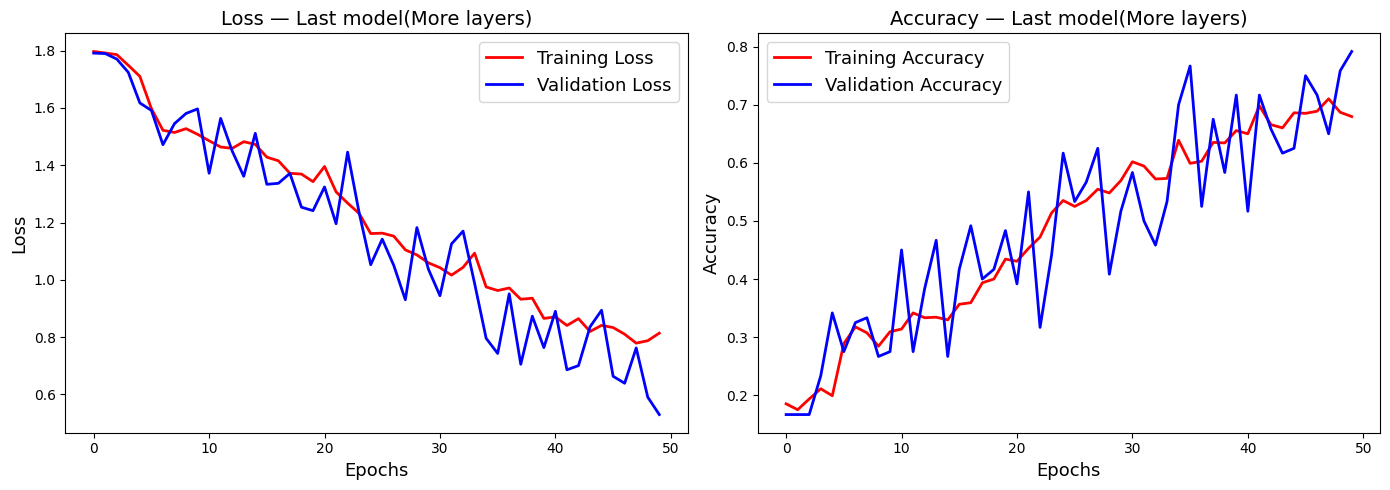

Last model — Test Loss: 0.5294, Test Accuracy: 0.7917


In [10]:
from keras.layers import Activation, GlobalAveragePooling2D
from keras import layers

data_augmentation_final = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

callback_final = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, verbose=1
)

model_final = Sequential([
    data_augmentation_final,

    Conv2D(32, (3, 3)),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3)),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3)),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    GlobalAveragePooling2D(),

    Flatten(),
    Dense(128),
    Activation('relu'),
    Dropout(0.5),

    Dense(nClasses, activation='softmax')
])

model_final.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_final = model_final.fit(
    X_train_norm, Y_train_oh,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_norm, Y_test_oh),
    callbacks=[callback_final]
)

model_final.summary()

print(f"X_train_norm.shape: {X_train_norm.shape}")
print(f"X_test_norm.shape:  {X_test_norm.shape}")

plot_history(history_final, 'Last model(More layers)')

loss, acc = model_final.evaluate(X_test_norm, Y_test_oh, verbose=0)
print(f'Last model — Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')


In [15]:
models_info = [
    ('Base', model_base),
    ('Data augm, early stop,3 layers', model2),
    ('Dropout 0.3 -> 0.6', model3),
    ('Tanh activation func', model4),
    ('Last model', model_final)
]

print(f'{"Модель":<30} | {"Test Loss":>10} | {"Test Accuracy":>14}')
print('-' * 60)
for name, m in models_info:
    l, a = m.evaluate(X_test_norm, Y_test_oh, verbose=0)
    print(f'{name:<30} | {l:>10.4f} | {a:>14.4f}')

Модель                         |  Test Loss |  Test Accuracy
------------------------------------------------------------
Base                           |     0.3030 |         0.9250
Data augm, early stop,3 layers |     0.3085 |         0.9167
Dropout 0.3 -> 0.6             |     0.3720 |         0.8417
Tanh activation func           |     0.2626 |         0.8750
Last model                     |     0.5294 |         0.7917


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


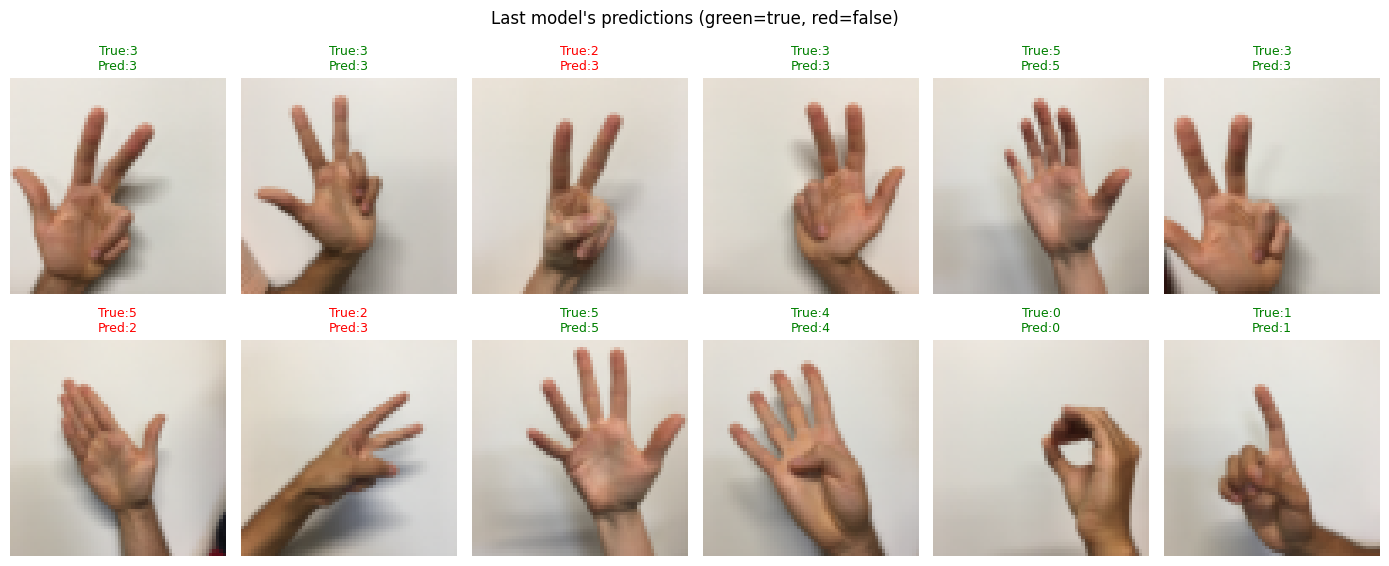

In [17]:
predict_probs = model_final.predict(X_test_norm)
predicted_classes = np.argmax(predict_probs, axis=1)

n = 12
indices = np.random.randint(0, len(test_data), n)

plt.figure(figsize=(14, 6))
for i, idx in enumerate(indices):
    ax = plt.subplot(2, 6, i + 1)
    ax.imshow(test_data[idx])
    true_label = Y_test_flat[idx]
    pred_label = predicted_classes[idx]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True:{true_label}\nPred:{pred_label}', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Last model's predictions (green=true, red=false)", fontsize=12)
plt.tight_layout()
plt.show()